# 固定 d 的 ER 图：六个 CD 算法 Training Score 下降曲线

本 Notebook 在**相同实验设定**（同一份固定 d 的 ER 数据）下，分别测试并可视化以下 6 个算法的训练分数下降情况：
1. `cd_A`
2. `cd_A_epoch`
3. `cd_B`
4. `cd_B_epoch`
5. `cd_BOmega`
6. `cd_BOmega_epoch`

每个算法在独立单元中运行与画图。

In [12]:
# 1) 环境、导入与固定实验设定
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

CURRENT_DIR = os.getcwd()
if os.path.exists(os.path.join(CURRENT_DIR, 'synthetic_dataset.py')):
    REPO_ROOT = CURRENT_DIR
elif os.path.basename(CURRENT_DIR) == 'experiments' and os.path.exists(os.path.join(CURRENT_DIR, '..', 'synthetic_dataset.py')):
    REPO_ROOT = os.path.abspath(os.path.join(CURRENT_DIR, '..'))
else:
    REPO_ROOT = os.path.abspath(os.path.join(CURRENT_DIR, '..'))
if REPO_ROOT not in sys.path:
    sys.path.append(REPO_ROOT)

os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

from synthetic_dataset import SyntheticDataset
from coordinate_descent.coordinate0 import (
    dag_coordinate_descent_l0,
    dag_coordinate_descent_l0_epoch,
    update_diagonal,
    update_off_diagonal,
    f as f_A,
)
from coordinate_descent.cd_B import (
    dag_coordinate_descent_B,
    dag_coordinate_descent_B_epoch,
    update_off_diagonal_B,
    f_B,
)
from coordinate_descent.cd_B_Omega import (
    dag_coordinate_descent_BOmega,
    dag_coordinate_descent_BOmega_epoch,
    update_off_diagonal_BOmega,
    update_Omega_closed_form,
    ell,
)

CFG = {
    'seed_data': 42,
    'seed_alg': 123,
    'n': 3000,
    'd': 20,
    'degree': 2.0,
    'noise_type': 'gaussian_nv',
    'b_scale': 5.0,
    'threshold': 0.05,
    'lambda_l0': 0.0,

    # non-epoch
    'T_non_epoch': 50000,

    # epoch
    'n_epochs': 500,
    'tol': 1e-4,
    'patience': 50,
    'min_epochs': 100,

    # B / BOmega
    'k': None,
    'dag_tol': 1e-8,
    'eps_omega': 1e-8,
}

dataset = SyntheticDataset(
    n=CFG['n'],
    d=CFG['d'],
    graph_type='ER',
    degree=CFG['degree'],
    noise_type=CFG['noise_type'],
    B_scale=CFG['b_scale'],
    seed=CFG['seed_data'],
)
X = dataset.X
S = X.T @ X / X.shape[0]

print('REPO_ROOT:', REPO_ROOT)
print('X shape  :', X.shape)
print('S shape  :', S.shape)
print('d fixed  :', CFG['d'])

REPO_ROOT: c:\Users\super\DAG
X shape  : (3000, 20)
S shape  : (20, 20)
d fixed  : 20


In [13]:
# 2) 公共工具：非 epoch 历史记录 + 画图
def run_cd_B_with_history(S, T, seed, lambda_l0=0.0, k=None, dag_tol=1e-8):
    np.random.seed(seed)
    d = S.shape[0]
    B = np.zeros((d, d))
    history = []
    for _ in range(T):
        i, j = np.random.choice(d, 2, replace=False)
        B = update_off_diagonal_B(
            B, S, i, j,
            lambda_l0=lambda_l0,
            k=k,
            dag_tol=dag_tol,
            debug_list=None,
        )
        history.append(float(f_B(B, S)))
    return B, history


def run_cd_BOmega_with_history(S, T, seed, lambda_l0=0.0, k=None, dag_tol=1e-8, eps_omega=1e-8):
    np.random.seed(seed)
    d = S.shape[0]
    B = np.zeros((d, d))
    Omega = np.eye(d)
    history = []
    for _ in range(T):
        i, j = np.random.choice(d, 2, replace=False)
        B = update_off_diagonal_BOmega(
            B, Omega, S, i, j,
            lambda_l0=lambda_l0,
            k=k,
            dag_tol=dag_tol,
            step=None,
            debug_list=None,
        )
        Omega = update_Omega_closed_form(B, S, eps=eps_omega)
        history.append(float(ell(B, Omega, S)))
    return B, Omega, history


def plot_history(history, title, x_label='iteration'):
    if history is None or len(history) == 0:
        print('Empty history.')
        return
    x = np.arange(1, len(history) + 1)
    plt.figure(figsize=(8, 4))
    plt.plot(x, history, linewidth=1.2)
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel('Training score')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    print('start:', float(history[0]), '| end:', float(history[-1]), '| len:', len(history))

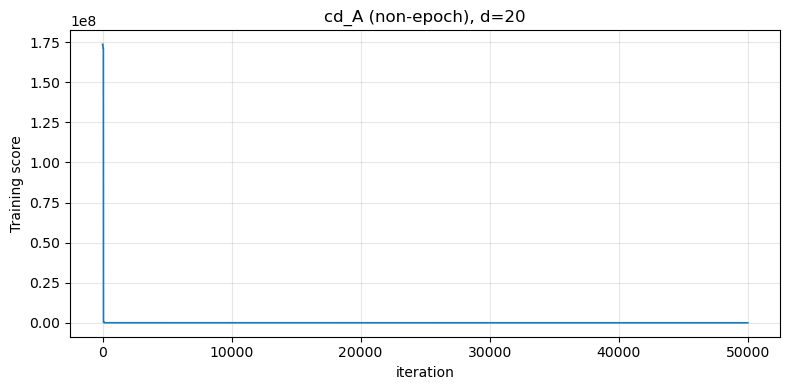

start: 173674663.04420364 | end: 186.4873495360855 | len: 50000


In [14]:
# 3) cd_A（non-epoch）
A_cdA, G_cdA, obj_cdA, hist_cdA = dag_coordinate_descent_l0(
    S=S,
    T=CFG['T_non_epoch'],
    seed=CFG['seed_alg'],
    threshold=CFG['threshold'],
    lambda_l0=CFG['lambda_l0'],
    return_history=True,
)
plot_history(hist_cdA, title=f"cd_A (non-epoch), d={CFG['d']}", x_label='iteration')

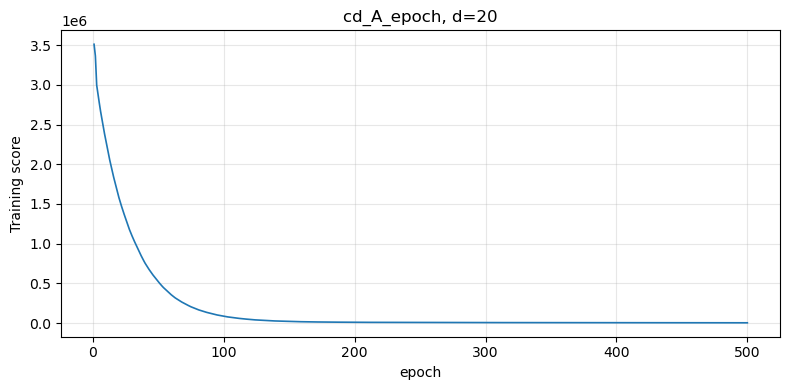

start: 3510792.035382675 | end: 3766.2101038853075 | len: 500


In [15]:
# 4) cd_A_epoch
A_cdA_ep, G_cdA_ep, obj_cdA_ep, hist_cdA_ep = dag_coordinate_descent_l0_epoch(
    S=S,
    n_epochs=CFG['n_epochs'],
    seed=CFG['seed_alg'],
    threshold=CFG['threshold'],
    lambda_l0=CFG['lambda_l0'],
    tol=CFG['tol'],
    patience=CFG['patience'],
    min_epochs=CFG['min_epochs'],
    verbose=False,
)
plot_history(hist_cdA_ep, title=f"cd_A_epoch, d={CFG['d']}", x_label='epoch')

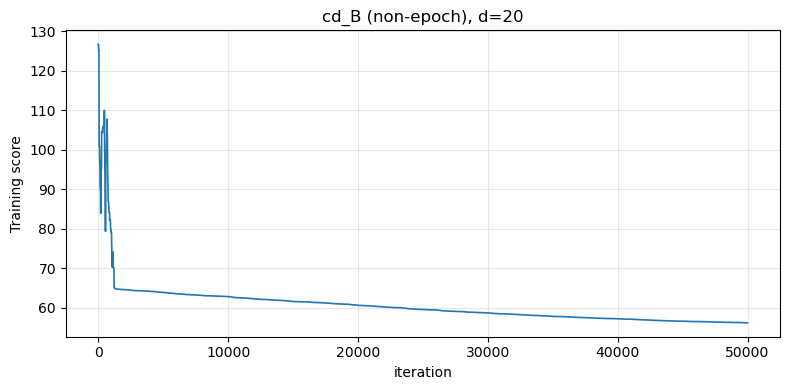

start: 126.7534538314323 | end: 56.20282915735533 | len: 50000


In [16]:
# 5) cd_B（non-epoch）
B_cdB, hist_cdB = run_cd_B_with_history(
    S=S,
    T=CFG['T_non_epoch'],
    seed=CFG['seed_alg'],
    lambda_l0=CFG['lambda_l0'],
    k=CFG['k'],
    dag_tol=CFG['dag_tol'],
)
plot_history(hist_cdB, title=f"cd_B (non-epoch), d={CFG['d']}", x_label='iteration')

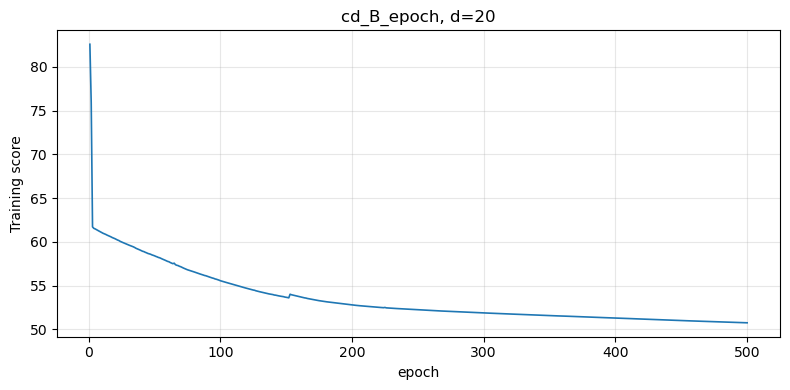

start: 82.57722407092922 | end: 50.744748305388136 | len: 500


In [17]:
# 6) cd_B_epoch
B_cdB_ep, G_cdB_ep, obj_cdB_ep, hist_cdB_ep, _ = dag_coordinate_descent_B_epoch(
    S=S,
    n_epochs=CFG['n_epochs'],
    seed=CFG['seed_alg'],
    threshold=CFG['threshold'],
    lambda_l0=CFG['lambda_l0'],
    k=CFG['k'],
    dag_tol=CFG['dag_tol'],
    tol=CFG['tol'],
    patience=CFG['patience'],
    min_epochs=CFG['min_epochs'],
    verbose=False,
)
plot_history(hist_cdB_ep, title=f"cd_B_epoch, d={CFG['d']}", x_label='epoch')

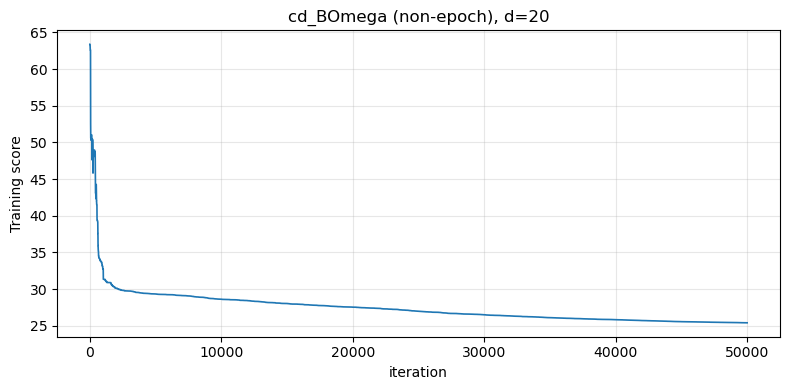

start: 63.37672691571426 | end: 25.404932021567873 | len: 50000


In [18]:
# 7) cd_BOmega（non-epoch）
B_cdBO, Omega_cdBO, hist_cdBO = run_cd_BOmega_with_history(
    S=S,
    T=CFG['T_non_epoch'],
    seed=CFG['seed_alg'],
    lambda_l0=CFG['lambda_l0'],
    k=CFG['k'],
    dag_tol=CFG['dag_tol'],
    eps_omega=CFG['eps_omega'],
)
plot_history(hist_cdBO, title=f"cd_BOmega (non-epoch), d={CFG['d']}", x_label='iteration')

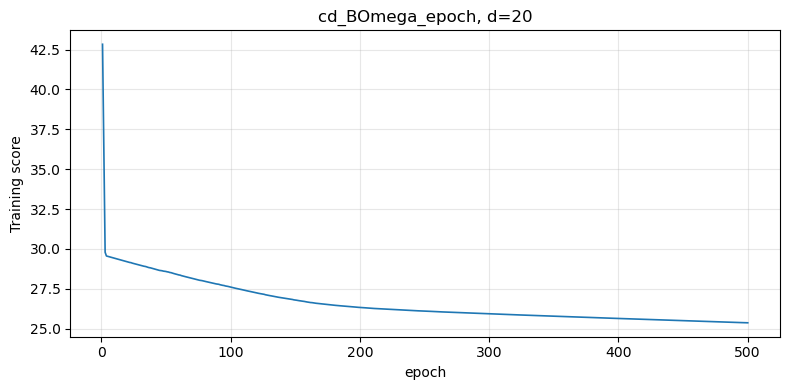

start: 42.82926053697497 | end: 25.374534813562505 | len: 500


In [19]:
# 8) cd_BOmega_epoch
B_cdBO_ep, G_cdBO_ep, obj_cdBO_ep, hist_cdBO_ep, _ = dag_coordinate_descent_BOmega_epoch(
    S=S,
    Omega=np.eye(CFG['d']),
    n_epochs=CFG['n_epochs'],
    seed=CFG['seed_alg'],
    threshold=CFG['threshold'],
    lambda_l0=CFG['lambda_l0'],
    k=CFG['k'],
    dag_tol=CFG['dag_tol'],
    tol=CFG['tol'],
    patience=CFG['patience'],
    min_epochs=CFG['min_epochs'],
    eps_omega=CFG['eps_omega'],
    verbose=False,
)
plot_history(hist_cdBO_ep, title=f"cd_BOmega_epoch, d={CFG['d']}", x_label='epoch')

In [20]:
# 9) 计算并打印 true_score（按各算法 objective）
# 由数据生成器恢复噪声方差，再构造精度 Omega
noise_meta = np.asarray(dataset.N)
if noise_meta.ndim == 0:
    var_diag = np.full(CFG['d'], float(noise_meta) ** 2)
elif noise_meta.ndim == 1:
    if noise_meta.size == CFG['d']:
        var_diag = np.square(noise_meta.astype(float))
    else:
        var_diag = np.full(CFG['d'], float(np.mean(noise_meta)) ** 2)
else:
    var_diag = np.var(noise_meta, axis=0, ddof=1)

var_diag = np.maximum(var_diag, 1e-12)
Omega_prec_true = np.diag(1.0 / var_diag)
Omega_sqrt_true = np.diag(np.sqrt(np.diag(Omega_prec_true)))

B_true = dataset.B.copy()
A_true = (np.eye(CFG['d']) - B_true) @ np.linalg.inv(Omega_sqrt_true)  # A = (I - B) Ω^{-1/2}

true_score_cd_A = float(f_A(A_true, S))
true_score_cd_B = float(f_B(B_true, S))
true_score_cd_BOmega = 2*float(ell(B_true, Omega_prec_true, S))

print('=== True Scores under fixed ER setting ===')
print(f"d={CFG['d']}, n={CFG['n']}, seed_data={CFG['seed_data']}")
print('true_score_cd_A      =', true_score_cd_A)
print('true_score_cd_B      =', true_score_cd_B)
print('true_score_cd_BOmega =', true_score_cd_BOmega)

true_scores = {
    'cd_A/cd_A_epoch': true_score_cd_A,
    'cd_B/cd_B_epoch': true_score_cd_B,
    'cd_BOmega/cd_BOmega_epoch': true_score_cd_BOmega,
}
true_scores

=== True Scores under fixed ER setting ===
d=20, n=3000, seed_data=42
true_score_cd_A      = 86.52135658674756
true_score_cd_B      = 35.638112528510504
true_score_cd_BOmega = 86.52135658022254


{'cd_A/cd_A_epoch': 86.52135658674756,
 'cd_B/cd_B_epoch': 35.638112528510504,
 'cd_BOmega/cd_BOmega_epoch': 86.52135658022254}